# real_groundtruth_multiregion.ipynb

Multi-region version of `real_groundtruth_downscale.ipynb`.

The four-scene protocol is a case study: tens of thousands of HEALPix cells,
but **four patches and one sensor**. This notebook runs the *same seven steps*
on **real Sentinel-2 patches at the 40 region anchors** already used by the
synthetic multi-region validation, so the real-data claim gets the same
statistical treatment as the synthetic one.

Note these are **Sentinel-2** acquisitions, not the Esri textures the
synthetic multi-region validation uses. They reuse only the *site list*.

**Statistical unit is the region.** One patch per region, ten regions per
scene class. The bootstrap below therefore resamples 10 independent values per
class -- a plain bootstrap over regions, not a cluster bootstrap (with a single
patch per region there is no within-region clustering left to absorb).

**Protocol** (identical to the four-scene notebook, see
`tests/real_groundtruth_common_tools.py`):

1. fetch a real, native 10 m Sentinel-2 B04 patch at the region anchor
2. PSF-aware resample the undegraded data to `NATIVE_LEVEL` (20)
3. plain no-PSF NESTED downgrade to `REF_LEVEL` (19) -- **the reference**
4. Gaussian-blur to the coarse effective resolution (FWHM 25 m)
5. point-sample every `BLOCK`-th pixel (20 m observation)
6. PSF-aware resample the coarse samples onto `REF_LEVEL`
7. compare against the reference, cell-for-cell, at `REF_LEVEL`

## Input data

The 40 patches are a **primary input**, archived like every other one:

```text
notebooks/data/multi_patch_sentinel2/region__<class>__<region_id>_data.zarr
```

They are covered by `notebooks/build_data_manifest.py`, so a normal run reads
them offline. Install the bundle with `load_data_in_zenodo.ipynb` first.

If they are not in the published archive yet, build them once with the
acquisition cell below, then rebuild the manifest and publish a new DOI.

**Prerequisite**: `tables/multi_patch_sites.csv` (written by
`multi_patch_latitude_validation.ipynb`) supplies the site list.

## Setup

In [17]:
import sys
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start=None, marker="healpix_resample"):
    """Walk upward until a directory containing `marker` is found."""
    p = Path(start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise RuntimeError(f"Could not locate the repo root above {p}.")


REPO_ROOT = find_repo_root()
MODULE_PATH = REPO_ROOT / "tests" / "real_groundtruth_common_tools.py"
print("module:", MODULE_PATH, "(exists:", MODULE_PATH.exists(), ")")

spec = importlib.util.spec_from_file_location("real_groundtruth_common_tools", MODULE_PATH)
gt = importlib.util.module_from_spec(spec)
spec.loader.exec_module(gt)

gt.describe_config()


module: /home/jovyan/healpix-resample/tests/real_groundtruth_common_tools.py (exists: True )
NATIVE_LEVEL=20: cell size ~= 6.22 m (reference built from real 10 m data, step 2)
REF_LEVEL=19:    cell size ~= 12.44 m (comparison level for every method, vs. 20 m coarse/degraded pixel, step 7)
DEGRADE_PSF_MODE='isotropic': FWHM_x=25.0 m, FWHM_y=25.0 m; isotropic reconstruction FWHM=25.0 m
EDGE_MARGIN_M=200 m excluded from every metric
REFERENCE_MODE='psf_aware', BASELINE_ESTIMAND='cell_average', MAX_ITER=14


## Step 0 -- register the 40 regions

One patch per region, taken at lattice position (1, 1), i.e. the region anchor
itself. The patch is chosen by **position, before any data is fetched or
scored**, so the selection cannot depend on the results.

In [18]:
scenes = gt.load_region_sites()          # patch_row=patch_col=1 by default
print(f"\n{len(scenes)} scenes registered, e.g.:")
for s in scenes[:3]:
    c = gt.region_coordinates[s]
    print(f"  {s:44s} {c['location']:22s} "
          f"lat={c['wgs84']['lat']:7.3f} lon={c['wgs84']['lon']:8.3f}")


Registered 40 regions (4 classes, {'urban': 10, 'water': 10, 'forest': 10, 'agriculture': 10}); 9 candidate patch position(s) each.

40 scenes registered, e.g.:
  region__urban__singapore                     Singapore              lat=  1.290 lon= 103.852
  region__urban__nairobi                       Nairobi, Kenya         lat= -1.286 lon=  36.817
  region__urban__sao_paulo                     Sao Paulo, Brazil      lat=-23.550 lon= -46.633


## Step 1 -- locate the Sentinel-2 patches

Read-only check against the frozen bundle. Nothing is downloaded here.

In [19]:
present = gt.check_region_sites()
available = present.loc[present.present, "scene"].tolist()
display(present[~present.present])
print(f"{len(available)} / {len(present)} region patches usable.")


17/40 region patches present under data/multi_patch_sentinel2.
Missing patches: install the frozen bundle (notebooks/load_data_in_zenodo.ipynb). If they are not in the archive yet, build them once with acquire_region_sites().


,scene,path,present
1,region__agriculture__canterbury,data/multi_patch_sentinel2/region__agriculture...,False
2,region__agriculture__iowa,data/multi_patch_sentinel2/region__agriculture...,False
3,region__agriculture__mato_grosso,data/multi_patch_sentinel2/region__agriculture...,False
5,region__agriculture__pampas,data/multi_patch_sentinel2/region__agriculture...,False
7,region__agriculture__punjab,data/multi_patch_sentinel2/region__agriculture...,False
10,region__forest__amazon,data/multi_patch_sentinel2/region__forest__ama...,False
13,region__forest__borneo,data/multi_patch_sentinel2/region__forest__bor...,False
15,region__forest__congo,data/multi_patch_sentinel2/region__forest__con...,False
17,region__forest__new_zealand,data/multi_patch_sentinel2/region__forest__new...,False
18,region__forest__patagonia,data/multi_patch_sentinel2/region__forest__pat...,False


17 / 40 region patches usable.


### One-off: building the bundle (skip if the archive already has it)

`acquire_region_sites()` is the only network call in this notebook and exists
to *construct* an input bundle, not to run an experiment. Run it once, then
rebuild the manifest and publish a new Zenodo version, then set `OFFLINE` back
to `True` so every later run reads archived copies.

A region with no cloud-free acquisition in `gt.REGION_DATE_WINDOW` fails here
and is skipped downstream -- a data-availability criterion, evaluated long
before any method is scored.

#### Preflight: the COG reader

The 40 region patches come from **Element 84's earth-search**, which holds the
complete Sentinel-2 L2A archive as Cloud-Optimized GeoTIFFs, so the same 40
sites as the synthetic validation are all reachable.

The EOPF STAC used for the four paper scenes is a European demonstration
catalogue: queried at these anchors it returned nothing outside Europe and
part of North America -- Amazon, Borneo, Congo, Punjab, Pampas, Tokyo,
Singapore and most of the southern hemisphere all gave `No items` even with a
four-year window at 40% cloud. That is coverage, not weather, so no filter
change could fix it.

Reading COGs needs `rasterio` (declared in the `notebooks` pixi feature):

    pixi run -e notebooks jupyter lab

In [20]:
print("source:", gt.REGION_STAC_SOURCE)
try:
    import rasterio
    print("rasterio", rasterio.__version__, "->", rasterio.__file__)
except ImportError as exc:
    print(f"rasterio is NOT importable ({exc}).\n"
          "Run this notebook with:  pixi run -e notebooks jupyter lab\n"
          "Avoid `!pip install` inside a pixi environment: a PyPI wheel "
          "shadowing conda's libproj is what breaks PROJ and the eopf-zarr "
          "backend (see the warning in pixi.toml).")


source: earth-search
rasterio 1.5.0 -> /srv/conda/envs/notebook/lib/python3.13/site-packages/rasterio/__init__.py


In [21]:
# Leave this cell unexecuted for a normal, offline run.
RUN_ACQUISITION = True

if RUN_ACQUISITION:
    gt.OFFLINE = False
    status = gt.acquire_region_sites()
    gt.OFFLINE = True
    display(status[status.status != "ok"])
    print("\nNow, from the repository root:")
    print("  python notebooks/build_data_manifest.py --doi <new DOI>")
    print("  python notebooks/build_data_manifest.py --check --doi <new DOI>")
    present = gt.check_region_sites()
    available = present.loc[present.present, "scene"].tolist()
else:
    print("Acquisition skipped; using the frozen bundle.")


[earth-search] sentinel-2-l2a at https://earth-search.aws.element84.com/v1, asset 'red'
[region__agriculture__beauce] cached  <- S2A_MSIL2A_20260812T105651_N0512_R094_T31UCP_20260812T192512  (2026-08-12T10:56:51.024000Z, cloud 0.005677%)
[  1/40] region__agriculture__beauce: ok
[region__agriculture__canterbury] 47 product(s); using S2A_59GNM_20240427_0_L2A (2024-04-27T22:28:24.346000Z, cloud 0.000919%, baseline 05.10)
[  2/40] region__agriculture__canterbury: ok
[region__agriculture__iowa] 154 product(s); using S2B_15TVG_20230908_1_L2A (2023-09-08T17:12:11.503000Z, cloud 1.7e-05%, baseline 05.11)
[  3/40] region__agriculture__iowa: ok
[region__agriculture__mato_grosso] 200 product(s); using S2C_21LWF_20250912_0_L2A (2025-09-12T14:06:28.362000Z, cloud 0.000401%, baseline 05.11)
[  4/40] region__agriculture__mato_grosso: ok
[region__agriculture__nile_delta] cached  <- S2A_MSIL2A_20241203T083331_N0511_R021_T36RTV_20241203T114054  (2024-12-03T08:33:31.024000Z, cloud 0.005711%)
[  5/40] reg

,scene,status,scene_class,region_id,patch_id,patch_row,patch_col,attempt,product_id,error
13,region__forest__borneo,failed,forest,borneo,,-1,-1,9,,9 position(s) tried; RuntimeError | last: Runt...



Now, from the repository root:
  python notebooks/build_data_manifest.py --doi <new DOI>
  python notebooks/build_data_manifest.py --check --doi <new DOI>
39/40 region patches present under data/multi_patch_sentinel2.
Missing patches: install the frozen bundle (notebooks/load_data_in_zenodo.ipynb). If they are not in the archive yet, build them once with acquire_region_sites().


## Input-quality screen

The STAC cloud filter is a **scene-level** percentage: a granule reported at
8% cloud can still have our 2.56 km patch entirely under a cloud, and a patch
near a granule edge can be mostly no-data. Both would enter the experiment
looking perfectly legitimate.

Every criterion below reads **only the input patch** -- never a reconstruction
or a score -- and runs before any method, so screening cannot favour any
method. Rejections go to `tables/real_groundtruth_multiregion_quality.csv`.

| Criterion | Threshold | Catches |
|---|---|---|
| shape | full `CENTRAL_SIZE` | patch clipped at a granule edge |
| finite fraction | `MIN_FINITE_FRACTION` = 0.99 | no-data holes |
| relative std | `MIN_RELATIVE_STD` = 1e-3 | flat patch, degenerate reference |
| bright fraction | `MAX_BRIGHT_FRACTION` = 0.30 above 0.30 reflectance | cloud or snow over the patch |

In [22]:
usable, quality = gt.screen_region_patches(available)
display(quality[["scene", "shape", "finite_fraction", "relative_std",
                 "bright_fraction", "usable", "flags"]])


/home/jovyan/healpix-resample/tests/real_groundtruth_common_tools.py:1760: RuntimeWarning: Mean of empty slice
  "delta_ci95_low": lo, "delta_ci95_high": hi})
/srv/conda/envs/notebook/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/jovyan/healpix-resample/tests/real_groundtruth_common_tools.py:1760: RuntimeWarning: Mean of empty slice
  "delta_ci95_low": lo, "delta_ci95_high": hi})
/srv/conda/envs/notebook/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


32/39 patches pass the input-quality screen.

Rejected (input properties only, before any method ran):
  region__agriculture__beauce                  <Flags(allows_duplicate_labels=True)>
  region__agriculture__nile_delta              <Flags(allows_duplicate_labels=True)>
  region__forest__appalachian                  <Flags(allows_duplicate_labels=True)>
  region__forest__canadian_rockies             <Flags(allows_duplicate_labels=True)>
  region__forest__tasmania                     <Flags(allows_duplicate_labels=True)>
  region__water__lake_baikal                   <Flags(allows_duplicate_labels=True)>
  region__water__lake_victoria                 <Flags(allows_duplicate_labels=True)>

Per class among the usable patches:
  agriculture      8
  forest           6
  urban           10
  water            8


,scene,shape,finite_fraction,relative_std,bright_fraction,usable,flags
0,region__agriculture__beauce,256x256,1.000000,0.467564,0.381256,False,bright 38% (cloud/snow?)
1,region__agriculture__canterbury,256x256,1.000000,0.663296,0.000031,True,
2,region__agriculture__iowa,256x256,1.000000,0.545096,0.000275,True,
3,region__agriculture__mato_grosso,256x256,1.000000,0.164511,0.002304,True,
4,region__agriculture__nile_delta,256x241,1.000000,0.409450,0.010568,False,too small (<256)
5,region__agriculture__pampas,256x256,1.000000,0.662380,0.006439,True,
6,region__agriculture__po_valley,256x256,1.000000,0.347414,0.025284,True,
7,region__agriculture__punjab,256x256,1.000000,0.541817,0.000275,True,
8,region__agriculture__ukraine,256x256,1.000000,0.416515,0.000946,True,
9,region__agriculture__western_australia,256x256,1.000000,0.287339,0.118942,True,


## Steps 2-7 -- run the protocol on every region

Same code path as the four-scene notebook: `run_all()` per scene, then the
per-region rows are concatenated with their scene class and region id.

In [23]:
metrics, failures = gt.run_multiregion(scenes=usable, force=False)

print()
print(metrics.groupby("scene_class").region_id.nunique().rename("regions").to_string())
display(failures)


[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.


/home/jovyan/healpix-resample/healpix_resample/psf.py:600: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1780240370028/work/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  self.MT = MT_coo.to_sparse_csr()


Itt 0 : 0.3039
Itt 4 : 0.004349
Itt 8 : 0.0002402
Itt 12 : 1.805e-05
Final Itt 13 : 9.605e-06
[  1/32] region__agriculture__canterbury: 5 rows
[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 0.6646
Itt 4 : 0.005635
Itt 8 : 0.0001705
Itt 12 : 1.549e-05
Final Itt 13 : 7.449e-06
[  2/32] region__agriculture__iowa: 5 rows
[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 0.2173
Itt 4 : 0.002633
Itt 8 : 0.0001719
Itt 12 : 1.338e-05
Final Itt 13 : 6.942e-06
[  3/32] region__agriculture__mato_grosso: 5 rows
[PSFResampler] area not provided and no shared-latitude-ring structure detected: falling back to a uniform weight of 1.0 per sample.
Itt 0 : 4.158
Itt 4 : 0.04659
Itt 8 : 0.002668
Itt 12 : 0.0002035
Final Itt 13 : 0.0001082
[  4/32] region__agriculture__pampas: 5 rows
[  5/32] region__agriculture__po_valley: 

""


## How many regions survived, and what that allows

Sentinel-2 availability, not statistics, sets the sample size here. Below
`gt.MIN_REGIONS_FOR_CI` regions a per-class bootstrap interval describes
*which sites happened to be usable*, not the class, so it is suppressed and
the class mean is reported as descriptive only.

In [24]:
availability = gt.region_availability(metrics)
display(availability)


32 regions analysed. Per-class breakdown:
  agriculture      8
  forest           6
  urban           10
  water            8


,scene_class,n_regions,per_class_ci_reportable
0,agriculture,8,True
1,forest,6,True
2,urban,10,True
3,water,8,True


### Primary statistic: pooled paired comparison

Every region counts once; each competitor is paired against PSF-aware *within
the same region*, so between-site scene variability cancels. The sign test is
exact and distribution-free, which is what this sample size calls for.

**This is the number to quote in the paper.**

In [25]:
pooled = gt.paired_summary(metrics)
display(pooled)

for _, r in pooled.iterrows():
    print(f"vs {r.competitor:20s} {int(r.psf_aware_wins):2d}/{int(r.n_regions):2d}"
          f"   sign-test p={r.sign_test_p:.3g}"
          f"   mean delta={r.mean_delta_rmse:+.5f} "
          f"[{r.delta_ci95_low:+.5f}, {r.delta_ci95_high:+.5f}]")


,competitor,n_regions,psf_aware_wins,win_fraction,sign_test_p,mean_delta_rmse,delta_ci95_low,delta_ci95_high
0,classical_cubic,32,32,1.0,4.656613e-10,0.004624,0.003193,0.006087
1,classical_linear,32,32,1.0,4.656613e-10,0.006201,0.004299,0.008157
2,classical_nearest,32,32,1.0,4.656613e-10,0.005627,0.003896,0.007421
3,richardson_lucy,32,32,1.0,4.656613e-10,0.002746,0.001878,0.003697


vs classical_cubic      32/32   sign-test p=4.66e-10   mean delta=+0.00462 [+0.00319, +0.00609]
vs classical_linear     32/32   sign-test p=4.66e-10   mean delta=+0.00620 [+0.00430, +0.00816]
vs classical_nearest    32/32   sign-test p=4.66e-10   mean delta=+0.00563 [+0.00390, +0.00742]
vs richardson_lucy      32/32   sign-test p=4.66e-10   mean delta=+0.00275 [+0.00188, +0.00370]


### The pooled result, as a figure

Left: one point per region, PSF-aware against each competitor, log-log with
the 1:1 line -- every point above the line is a region PSF-aware wins. Right:
mean paired difference with bootstrap interval, annotated with wins/n and the
exact sign test.

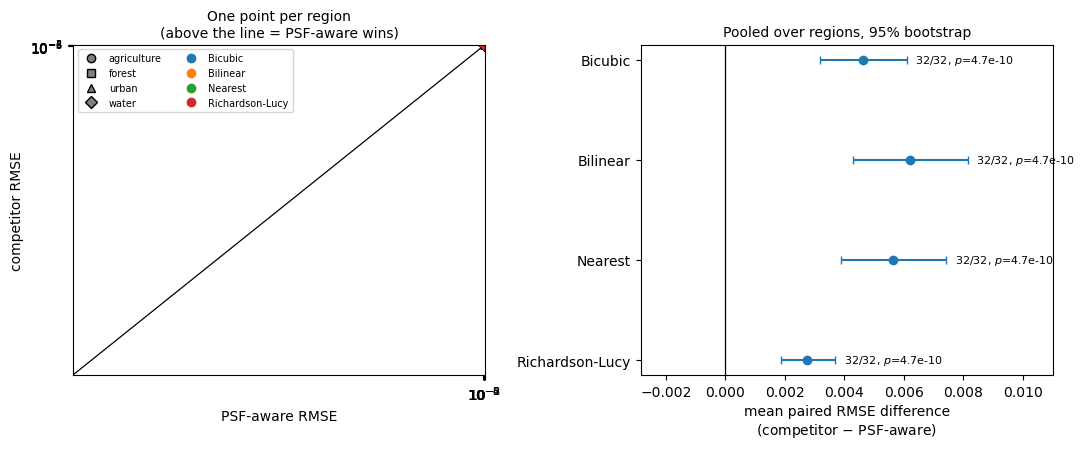

In [26]:
fig = gt.plot_paired_summary(metrics, pooled)


### Secondary: per-class breakdown (descriptive where n is small)

## Region-level aggregation

Per scene class: mean RMSE per method over regions with a percentile bootstrap
interval, and the paired per-region difference against PSF-aware.

In [27]:
summary, comparisons = gt.summarize_multiregion(metrics)
display(summary)


,scene_class,method,n_regions,mean_rmse,rmse_ci95_low,rmse_ci95_high,ci_reportable,between_region_sd
0,agriculture,classical_cubic,8,0.013808,0.009745,0.019158,True,0.007394
1,agriculture,classical_linear,8,0.015061,0.010737,0.020703,True,0.007820
2,agriculture,classical_nearest,8,0.014681,0.010480,0.020131,True,0.007562
3,agriculture,psf_aware,8,0.010338,0.007107,0.014641,True,0.005975
4,agriculture,richardson_lucy,8,0.012251,0.008760,0.016971,True,0.006596
5,forest,classical_cubic,6,0.020367,0.006403,0.035394,True,0.020393
6,forest,classical_linear,6,0.022317,0.006933,0.039322,True,0.022585
7,forest,classical_nearest,6,0.021748,0.006757,0.038357,True,0.022027
8,forest,psf_aware,6,0.014891,0.004812,0.025213,True,0.014642
9,forest,richardson_lucy,6,0.018114,0.006007,0.030923,True,0.017553


In [28]:
display(comparisons[["scene_class", "competitor", "n_regions",
                     "mean_delta_rmse_competitor_minus_matched",
                     "delta_ci95_low", "delta_ci95_high",
                     "matched_win_fraction"]])

print("win fraction 1.0 everywhere:", bool((comparisons.matched_win_fraction == 1).all()))
print("every paired interval excludes zero:", bool((comparisons.delta_ci95_low > 0).all()))


,scene_class,competitor,n_regions,mean_delta_rmse_competitor_minus_matched,delta_ci95_low,delta_ci95_high,matched_win_fraction
0,agriculture,classical_cubic,8,0.003470,0.002578,0.004511,1.0
1,forest,classical_cubic,6,0.005476,0.001591,0.010441,1.0
2,urban,classical_cubic,10,0.008502,0.007074,0.009884,1.0
3,water,classical_cubic,8,0.000290,0.000087,0.000575,1.0
4,agriculture,classical_linear,8,0.004722,0.003545,0.006071,1.0
5,forest,classical_linear,6,0.007426,0.002121,0.014283,1.0
6,urban,classical_linear,10,0.011291,0.009428,0.013137,1.0
7,water,classical_linear,8,0.000400,0.000114,0.000801,1.0
8,agriculture,classical_nearest,8,0.004342,0.003279,0.005528,1.0
9,forest,classical_nearest,6,0.006857,0.001945,0.013343,1.0


win fraction 1.0 everywhere: True
every paired interval excludes zero: True


## Paper table

In [29]:
table = gt.format_multiregion_table(summary, comparisons)
display(table)


,Scene class,Regions,PSF-aware RMSE,Nearest-neighbor RMSE,Nearest-neighbor delta,Nearest-neighbor delta lo,Nearest-neighbor delta hi,Nearest-neighbor win,Bilinear RMSE,Bilinear delta,...,Bicubic RMSE,Bicubic delta,Bicubic delta lo,Bicubic delta hi,Bicubic win,Richardson-Lucy RMSE,Richardson-Lucy delta,Richardson-Lucy delta lo,Richardson-Lucy delta hi,Richardson-Lucy win
0,agriculture,8,0.010338,0.014681,0.004342,0.003279,0.005528,1.0,0.015061,0.004722,...,0.013808,0.003470,0.002578,0.004511,1.0,0.012251,0.001913,0.001365,0.002507,1.0
1,forest,6,0.014891,0.021748,0.006857,0.001945,0.013343,1.0,0.022317,0.007426,...,0.020367,0.005476,0.001591,0.010441,1.0,0.018114,0.003223,0.001045,0.006064,1.0
2,urban,10,0.026942,0.037053,0.010110,0.008456,0.011793,1.0,0.038233,0.011291,...,0.035444,0.008502,0.007074,0.009884,1.0,0.032139,0.005197,0.004030,0.006669,1.0
3,water,8,0.001189,0.001575,0.000386,0.000102,0.000794,1.0,0.001589,0.000400,...,0.001479,0.000290,0.000087,0.000575,1.0,0.001345,0.000156,0.000047,0.000309,1.0


## Figure -- per-class RMSE with bootstrap intervals

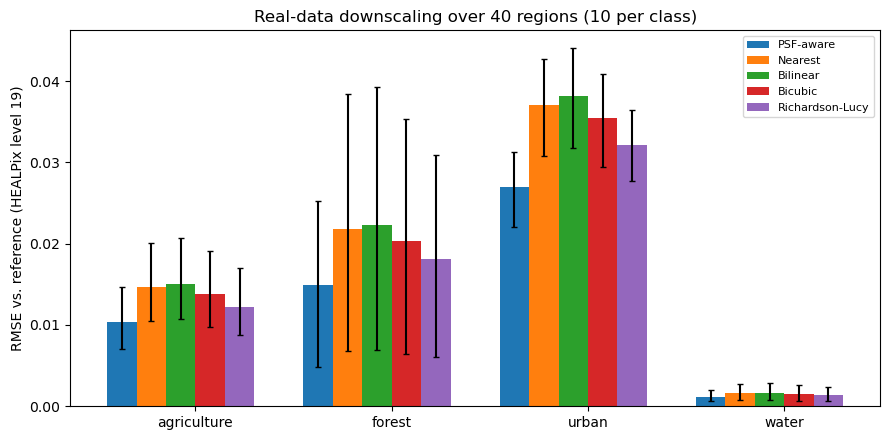

In [30]:
methods = ["psf_aware", "classical_nearest", "classical_linear",
           "classical_cubic", "richardson_lucy"]
labels = {"psf_aware": "PSF-aware", "classical_nearest": "Nearest",
          "classical_linear": "Bilinear", "classical_cubic": "Bicubic",
          "richardson_lucy": "Richardson-Lucy"}
classes = sorted(summary.scene_class.unique())

fig, ax = plt.subplots(figsize=(9, 4.5))
width = 0.15
x = np.arange(len(classes))
for i, m in enumerate(methods):
    sub = summary[summary.method == m].set_index("scene_class")
    vals = [sub.loc[c, "mean_rmse"] if c in sub.index else np.nan for c in classes]
    lo = [sub.loc[c, "mean_rmse"] - sub.loc[c, "rmse_ci95_low"] if c in sub.index else 0 for c in classes]
    hi = [sub.loc[c, "rmse_ci95_high"] - sub.loc[c, "mean_rmse"] if c in sub.index else 0 for c in classes]
    ax.bar(x + (i - len(methods) / 2) * width, vals, width,
           yerr=[lo, hi], capsize=2, label=labels[m])
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel(f"RMSE vs. reference (HEALPix level {gt.REF_LEVEL})")
ax.set_title("Real-data downscaling over 40 regions (10 per class)")
ax.legend(fontsize=8)
fig.tight_layout()
gt.FIG_DIR.mkdir(exist_ok=True)
fig.savefig(gt.FIG_DIR / "real_groundtruth_multiregion_rmse.pdf", dpi=200)


## Width-mismatch control (real-data analogue of the +-50% arms)

The degradation stays at 25 m; only the **assumed** reconstruction width
changes. Note the asymmetry that makes this informative: only PSF-aware and
Richardson--Lucy use the assumed width, so a width error costs exactly the two
response-modelling methods and leaves the geometric baselines untouched.

Run on the four benchmark scenes first (cheap); pass `scenes=available` to
repeat it over all 40 regions.

In [31]:
df_wide   = gt.run_width_mismatch(scale=1.5)   # overestimated response
df_narrow = gt.run_width_mismatch(scale=0.5)   # underestimated response
df_matched = gt.run_all(force=False)

comp = (df_matched[["scene", "method", "rmse"]]
        .merge(df_wide[["scene", "method", "rmse"]], on=["scene", "method"],
               suffixes=("_matched", "_plus50"))
        .merge(df_narrow[["scene", "method", "rmse"]].rename(columns={"rmse": "rmse_minus50"}),
               on=["scene", "method"]))
comp["plus50_pct"] = 100 * (comp.rmse_plus50 - comp.rmse_matched) / comp.rmse_matched
comp["minus50_pct"] = 100 * (comp.rmse_minus50 - comp.rmse_matched) / comp.rmse_matched
display(comp)


,scene,method,rmse_matched,rmse_plus50,rmse_minus50,plus50_pct,minus50_pct
0,urban,psf_aware,0.027182,0.034689,0.034920,2.761614e+01,2.846894e+01
1,urban,classical_nearest,0.036431,0.036431,0.036431,1.660952e-06,1.954168e-06
2,urban,classical_linear,0.037736,0.037736,0.037736,1.870704e-06,2.028956e-06
3,urban,classical_cubic,0.035285,0.035285,0.035285,2.114288e-06,2.214272e-06
4,urban,richardson_lucy,0.035386,0.038192,0.038949,7.929240e+00,1.006748e+01
5,water,psf_aware,0.008972,0.011061,0.011291,2.328780e+01,2.584451e+01
6,water,classical_nearest,0.011714,0.011714,0.011714,-8.293781e-08,3.774895e-07
7,water,classical_linear,0.012077,0.012077,0.012077,-2.178669e-07,4.050360e-07
8,water,classical_cubic,0.011308,0.011308,0.011308,-1.434292e-07,4.581966e-07
9,water,richardson_lucy,0.010370,0.011526,0.011756,1.114975e+01,1.336224e+01


## Notes

- Every result-changing setting (`REF_LEVEL`, `BLOCK`, `RECON_FWHM_M`,
  `MAX_ITER`, `REFERENCE_MODE`, `BASELINE_ESTIMAND`, degradation mode) is
  encoded in the cache and CSV filenames via `gt._cache_suffix()`, so variants
  never overwrite each other or the four-scene result the paper's Table VI is
  built from.
- `gt.run_multiregion()` skips a region only when its patch is missing or its
  reference is degenerate. Both criteria are evaluated before any method is
  scored.
- To rerun everything from scratch, pass `force=True`; otherwise cached
  intermediate `.npz` files are reused.

## Publish the paper assets

`tex/figures/` and `tex/tables/` are separate copies of what this notebook
writes. Publishing them here keeps the compiled paper in step with the last
run instead of relying on a manual copy.

In [32]:
# Publish notebook outputs into tex/figures and tex/tables.
#
# Loaded by file path rather than by `import`: the module lives in the same
# repository as this notebook, but a checkout that has not been synced yet
# would otherwise fail with a bare ModuleNotFoundError at the very end of a
# long run. Here a missing file says so, and says where it should be.
import importlib.util
from pathlib import Path


def _repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for c in (p, *p.parents):
        if (c / "healpix_resample").is_dir() and (c / "notebooks").is_dir():
            return c
    raise RuntimeError(f"healpix-resample checkout not found above {p}")


_pub = _repo_root() / "notebooks" / "publish_paper_assets.py"
if not _pub.exists():
    print(f"publish_paper_assets.py not found at {_pub}\n"
          f"Nothing was published: tex/figures and tex/tables still hold the\n"
          f"previous run's assets. Sync the repository, then re-run this cell,\n"
          f"or from the repository root:\n"
          f"    python notebooks/publish_paper_assets.py")
else:
    _spec = importlib.util.spec_from_file_location("publish_paper_assets", _pub)
    _mod = importlib.util.module_from_spec(_spec)
    _spec.loader.exec_module(_mod)
    _mod.publish()


publish_paper_assets: 12 figures cited by main.tex, 18 declared table CSVs
  added          : 18
      tables/table_I_synthetic.csv
      tables/table_II_roundtrip.csv
      tables/table_ablation_rl_fair.csv
      tables/estimand_point_vs_average.csv
      tables/holdout_validation.csv
      tables/multi_patch_latitude_summary.csv
      tables/multi_patch_method_comparisons.csv
      tables/multi_patch_two_stage_40_summary.csv
      tables/multi_patch_two_stage_40_comparisons.csv
      tables/multi_patch_run_summary.csv
      tables/multi_patch_runtime_by_method.csv
      tables/real_groundtruth_downscale_table.csv
      tables/real_groundtruth_downscale_metrics.csv
      tables/real_groundtruth_downscale_anisotropic_24x45_table.csv
      tables/noise_sensitivity_psf_mismatch.csv
      tables/geolocation_sensitivity.csv
      tables/throughput_scaling_by_batch.csv
      tables/throughput_scaling_environment.csv
  newer-in-tex   : 2
      figures/scene_types.pdf
      figures/real_groun